# 02: First DC-AC Superimposed Current Injection

**Goal**: Inject a DC + AC sinusoidal current into PyBaMM via `Interpolant`, observe voltage ripple in the response.

**Setup**:
- Model: SPMe with lumped thermal (Chen2020 parameter set)
- DC current: 1C (= nominal capacity)
- AC amplitude: 0.5 A (= 10% of DC)
- AC frequency: 1 Hz (low frequency, easy to visualize)
- Simulation duration: 10 seconds (10 AC cycles)

**Rationale for starting at 1 Hz**: debugging visibility. Higher frequencies will be explored in subsequent notebooks.

In [1]:
import pybamm
import numpy as np
import matplotlib.pyplot as plt

# Simulation parameters
I_dc = 5.0          # DC current [A] (= 1C for Chen2020 5 Ah cell)
I_ac = 0.5          # AC amplitude [A] (10% of DC)
f_ac = 1.0          # AC frequency [Hz]
t_end = 10.0        # Total simulation time [s]
dt = 0.01           # Time resolution of input waveform [s]
                    # At 1 Hz AC, 0.01s = 100 samples per cycle → safe

# Build time and current arrays
t_array = np.arange(0, t_end + dt, dt)
I_array = I_dc + I_ac * np.sin(2 * np.pi * f_ac * t_array)

print(f"Number of samples: {len(t_array)}")
print(f"Time span: 0 to {t_array[-1]} s")
print(f"Current range: {I_array.min():.3f} A to {I_array.max():.3f} A")
print(f"Mean current: {I_array.mean():.3f} A (should be ~{I_dc})")

Number of samples: 1001
Time span: 0 to 10.0 s
Current range: 4.500 A to 5.500 A
Mean current: 5.000 A (should be ~5.0)


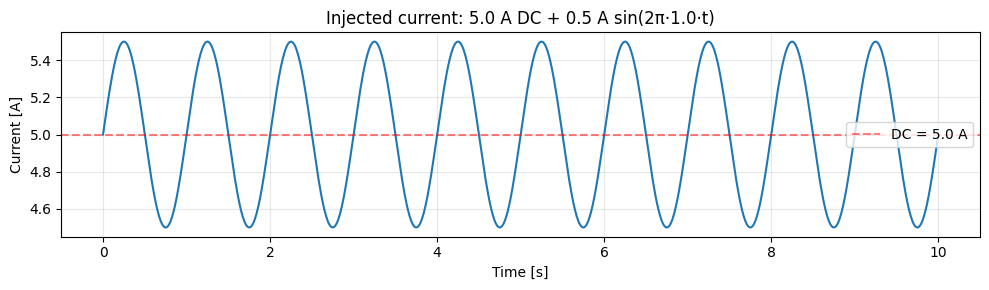

In [2]:
fig, ax = plt.subplots(1, 1, figsize=(10, 3))
ax.plot(t_array, I_array, linewidth=1.5)
ax.axhline(I_dc, color='red', linestyle='--', alpha=0.5, label=f'DC = {I_dc} A')
ax.set_xlabel("Time [s]")
ax.set_ylabel("Current [A]")
ax.set_title(f"Injected current: {I_dc} A DC + {I_ac} A sin(2π·{f_ac}·t)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [3]:
# Build model
model = pybamm.lithium_ion.SPMe(options={"thermal": "lumped"})

# Build parameter set
parameter_values = pybamm.ParameterValues("Chen2020")

# Create an Interpolant: a PyBaMM object that represents a time-dependent function
# Inputs:
#   - t_array: the time points where current is defined
#   - I_array: the corresponding current values
#   - pybamm.t: PyBaMM's symbolic time variable (crucial — this tells PyBaMM 
#     "evaluate the interpolant at the current simulation time")
current_interpolant = pybamm.Interpolant(
    t_array, 
    I_array, 
    pybamm.t, 
    name="DC-AC current"
)

# Assign to parameter set
parameter_values["Current function [A]"] = current_interpolant

print("Current function assigned as Interpolant.")
print(f"  Type: {type(parameter_values['Current function [A]']).__name__}")

Current function assigned as Interpolant.
  Type: Interpolant


In [6]:
sim = pybamm.Simulation(model, parameter_values=parameter_values)

# Give the solver explicit output times (dense) so we capture the AC ripple
t_eval = np.arange(0, t_end + dt, dt)
solution = sim.solve(t_eval=t_eval)

print(f"Simulation finished.")
print(f"  Solved time: 0 to {solution.t[-1]:.2f} s")
print(f"  Number of output points: {len(solution.t)}")

Simulation finished.
  Solved time: 0 to 10.00 s
  Number of output points: 3571


In [7]:
# Diagnose: is the time sampling uniform?
dt_samples = np.diff(solution.t)
print(f"Number of time points: {len(solution.t)}")
print(f"Min dt: {dt_samples.min()*1000:.3f} ms")
print(f"Max dt: {dt_samples.max()*1000:.3f} ms")
print(f"Mean dt: {dt_samples.mean()*1000:.3f} ms")
print(f"dt std / dt mean: {dt_samples.std()/dt_samples.mean():.3f}")
print()
print(f"Requested t_eval points: {len(t_eval)}")
print(f"Actual output points: {len(solution.t)}")
print(f"Ratio (actual/requested): {len(solution.t)/len(t_eval):.2f}x")

Number of time points: 3571
Min dt: 0.010 ms
Max dt: 5.000 ms
Mean dt: 2.801 ms
dt std / dt mean: 0.426

Requested t_eval points: 1001
Actual output points: 3571
Ratio (actual/requested): 3.57x


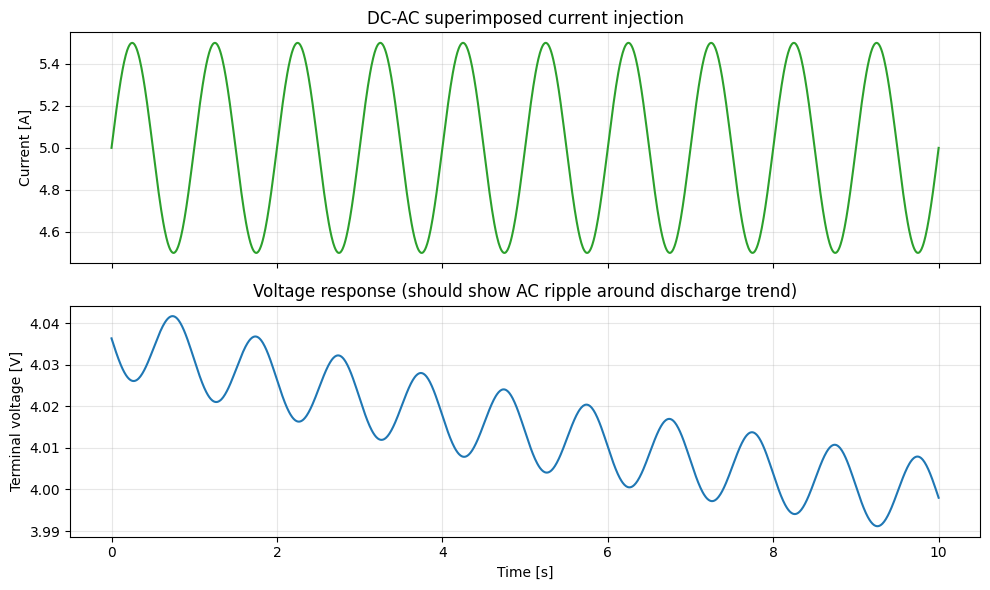

Mean voltage over 10 s: 4.0136 V
Peak-to-peak voltage variation: 50.54 mV


In [8]:
t_sol = solution.t
V_sol = solution["Terminal voltage [V]"].entries
I_sol = solution["Current [A]"].entries

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

# Top: injected current (from solution, should match what we built)
ax1.plot(t_sol, I_sol, color='tab:green', linewidth=1.5)
ax1.set_ylabel("Current [A]")
ax1.set_title("DC-AC superimposed current injection")
ax1.grid(True, alpha=0.3)

# Bottom: voltage response
ax2.plot(t_sol, V_sol, color='tab:blue', linewidth=1.5)
ax2.set_xlabel("Time [s]")
ax2.set_ylabel("Terminal voltage [V]")
ax2.set_title("Voltage response (should show AC ripple around discharge trend)")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Quick numerical summary
V_mean = V_sol.mean()
V_ripple_pp = V_sol.max() - V_sol.min()
print(f"Mean voltage over 10 s: {V_mean:.4f} V")
print(f"Peak-to-peak voltage variation: {V_ripple_pp*1000:.2f} mV")

In [9]:
# 用一个更激进的对比验证符号约定
# 短时间 (1 s) 纯 DC，看电压往哪跑

# Case 1: I = +5 A (预期放电，电压降)
pv_test = pybamm.ParameterValues("Chen2020")
pv_test["Current function [A]"] = 5.0
sim_test = pybamm.Simulation(model, parameter_values=pv_test)
sol_pos = sim_test.solve(t_eval=np.linspace(0, 1, 101))

# Case 2: I = -5 A (预期充电,电压升)
pv_test2 = pybamm.ParameterValues("Chen2020")
pv_test2["Current function [A]"] = -5.0
sim_test2 = pybamm.Simulation(model, parameter_values=pv_test2)
sol_neg = sim_test2.solve(t_eval=np.linspace(0, 1, 101))

V_pos = sol_pos["Terminal voltage [V]"].entries
V_neg = sol_neg["Terminal voltage [V]"].entries

print(f"I = +5 A:  V(0) = {V_pos[0]:.4f}, V(1) = {V_pos[-1]:.4f}, ΔV = {V_pos[-1]-V_pos[0]*1000:.2f} mV")
print(f"I = -5 A:  V(0) = {V_neg[0]:.4f}, V(1) = {V_neg[-1]:.4f}, ΔV = {V_neg[-1]-V_neg[0]*1000:.2f} mV")

SolverError: Events ['Maximum voltage [V]'] are non-positive at initial conditions with inputs {}

In [10]:
# Case 2: I = -5 A (预期充电,电压升)
# 关键修改：从 10% SOC 启动，给充电留电压空间
pv_test2 = pybamm.ParameterValues("Chen2020")
pv_test2["Current function [A]"] = -5.0
sim_test2 = pybamm.Simulation(model, parameter_values=pv_test2)
sol_neg = sim_test2.solve(t_eval=np.linspace(0, 1, 101), initial_soc=0.1)

V_pos = sol_pos["Terminal voltage [V]"].entries
V_neg = sol_neg["Terminal voltage [V]"].entries

print(f"I = +5 A:  V(0) = {V_pos[0]:.4f}, V(1) = {V_pos[-1]:.4f}, ΔV = {(V_pos[-1]-V_pos[0])*1000:.2f} mV")
print(f"I = -5 A:  V(0) = {V_neg[0]:.4f}, V(1) = {V_neg[-1]:.4f}, ΔV = {(V_neg[-1]-V_neg[0])*1000:.2f} mV")

I = +5 A:  V(0) = 4.0363, V(1) = 4.0312, ΔV = -5.15 mV
I = -5 A:  V(0) = 3.4386, V(1) = 3.4478, ΔV = 9.22 mV
